# Question set 1 - ground truth analysis 

Each question below was answered through: 
1) a series of manual data analysis steps
2) a series of tool calls using pre-defined functions from tools.py. 

Notes for agent design:
- Data analysis is hard! Each question requires lots of nuanced decisions about how to transform the data and efficiently produce an output that best answers the question. 
- There are many different ways of presenting the final answer. The level of detail needed to provide the user with actionable and calibrated insights can be subjective.
- Some questions require defining your own metric e.g. polarisation in D3. 2 experiments:
1. Agents can only use my pre-defined tools
2. Agents are free to write their own functions 
- Hypothesis 1: When given access to a standard set of tools, agents can more efficiently reach a moderately accurate answer with lower cost and lower latency.
- Hypothesis 2: When given access to an open Python sandbox, agents can come up with more insightful answers, but incur higher cost and higher latency.

- Each agent is given the clean_fabsa.csv loaded as a dataframe (df) at initialisation. All tool calls operate on this dataframe or outputs derived from it. Data loading is not a step that is tracked or scored in the benchmark.
- The final LLM response is not a tool call. We want to test whether the agent produces text grounded in the tool outputs. e.g. if tool accuracy is 100%, is insight accuracy also 100%?

## Load data

In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
import sys
sys.path.insert(0, "../src")
from cx_agent.tools import filter_data, exclude, count_by, sentiment_breakdown, add_shares, add_polarisation, apply_min_volume, rank_top, share_of, chi_squared  # sample_reviews disabled (labels-only corpus)

In [30]:
df = pd.read_csv("clean_fabsa.csv")
df.head()

,id,org_index,data_source,industry,text,parent_aspect,child_aspect,sentiment
0,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,staff-support,attitude-of-staff,negative
1,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,company-brand,reviews,negative
2,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,company-brand,general-satisfaction,negative
3,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...",company-brand,general-satisfaction,positive
4,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...",company-brand,competitor,positive


In [31]:
df.shape

(13998, 8)

In [4]:
# check column values
print("industries :", sorted(df["industry"].unique()))
print("data sources    :", sorted(df["data_source"].unique()))
print("parent aspects    :", sorted(df["parent_aspect"].unique()))
print("child aspects    :", sorted(df["child_aspect"].unique()))
print("sentiments:", sorted(df["sentiment"].unique()))

industries : ['Banking', 'Consulting', 'Fashion', 'Groceries', 'Information Technology', 'Price Comparison', 'Ride Hailing', 'Streaming', 'Trading', 'Travel Booking']
data sources    : ['Apple Store', 'Google Play', 'Trustpilot']
parent aspects    : ['account-management', 'company-brand', 'logistics-rides', 'online-experience', 'purchase-booking-experience', 'staff-support', 'value']
child aspects    : ['account-access', 'app-website', 'attitude-of-staff', 'competitor', 'discounts-promotions', 'ease-of-use', 'email', 'general-satisfaction', 'phone', 'price-value-for-money', 'reviews', 'speed']
sentiments: ['negative', 'neutral', 'positive']


## Descriptive queries

### D1. What are the top 3 complaints about our fashion brand (org_index = 727) on Google Play?

In [5]:
# filter relevant subset
mask_d1 = (
    (df['org_index'] == 727) & (df['data_source'] == "Google Play") & (df['sentiment']=="negative")
)
df_d1 = df[mask_d1]
df_d1.head()

,id,org_index,data_source,industry,text,parent_aspect,child_aspect,sentiment
184,301988452,727,Google Play,Fashion,"""Currently experiencing technical difficulties...",online-experience,app-website,negative
234,301987696,727,Google Play,Fashion,My app dosen't work it keeps saying error,online-experience,app-website,negative
288,301987729,727,Google Play,Fashion,Great app / it does have its bugs at times,online-experience,app-website,negative
550,301987629,727,Google Play,Fashion,"It's okay, functional but clunky with my S9+.",online-experience,app-website,negative
788,301988256,727,Google Play,Fashion,Before this pandemic the workers were so warm ...,staff-support,attitude-of-staff,negative


In [6]:
# group by child aspect and count reviews
df_d1.groupby('child_aspect').size().reset_index(name = "volume").sort_values ("volume", ascending = False)

,child_aspect,volume
1,app-website,76
0,account-access,13
7,general-satisfaction,13
10,speed,11
5,ease-of-use,10
2,attitude-of-staff,8
4,discounts-promotions,6
9,reviews,2
3,competitor,1
6,email,1


Gold answer: The top 3 complaints on Google Play are about app/website experience (n=76), account access (n=13) and general satisfaction (n=13).

### D1 tool path

In [ ]:
d1_step1 = filter_data(df, sentiment='negative', org_index=727, data_source='Google Play')

In [8]:
d1_step2 = count_by(d1_step1, 'child_aspect')
d1_step2

,child_aspect,count
0,app-website,76
1,account-access,13
2,general-satisfaction,13
3,speed,11
4,ease-of-use,10
5,attitude-of-staff,8
6,discounts-promotions,6
7,reviews,2
8,competitor,1
9,email,1


### D2. How does sentiment break down by parent aspect across ride-hailing?

In [9]:
# filter
df_d2 = df[df['industry']=="Ride Hailing"]

In [10]:
# count parent aspects for each sentiment
d2_counts = df_d2.groupby(['parent_aspect', 'sentiment']).size().reset_index(name='count')
d2_counts.head(3)

,parent_aspect,sentiment,count
0,account-management,negative,26
1,company-brand,negative,102
2,company-brand,neutral,5


In [11]:
# calculate totals and percentages
d2_counts["total"] = d2_counts.groupby('parent_aspect')['count'].transform('sum')
d2_counts["percentage"] = d2_counts['count'] / d2_counts["total"] * 100
d2_counts.sort_values(['parent_aspect', 'sentiment'], ascending=[True, False], inplace=True)
d2_counts


,parent_aspect,sentiment,count,total,percentage
0,account-management,negative,26,26,100.000000
3,company-brand,positive,60,167,35.928144
2,company-brand,neutral,5,167,2.994012
1,company-brand,negative,102,167,61.077844
5,logistics-rides,positive,11,27,40.740741
4,logistics-rides,negative,16,27,59.259259
8,online-experience,positive,25,152,16.447368
7,online-experience,neutral,4,152,2.631579
6,online-experience,negative,123,152,80.921053
11,purchase-booking-experience,positive,7,70,10.000000


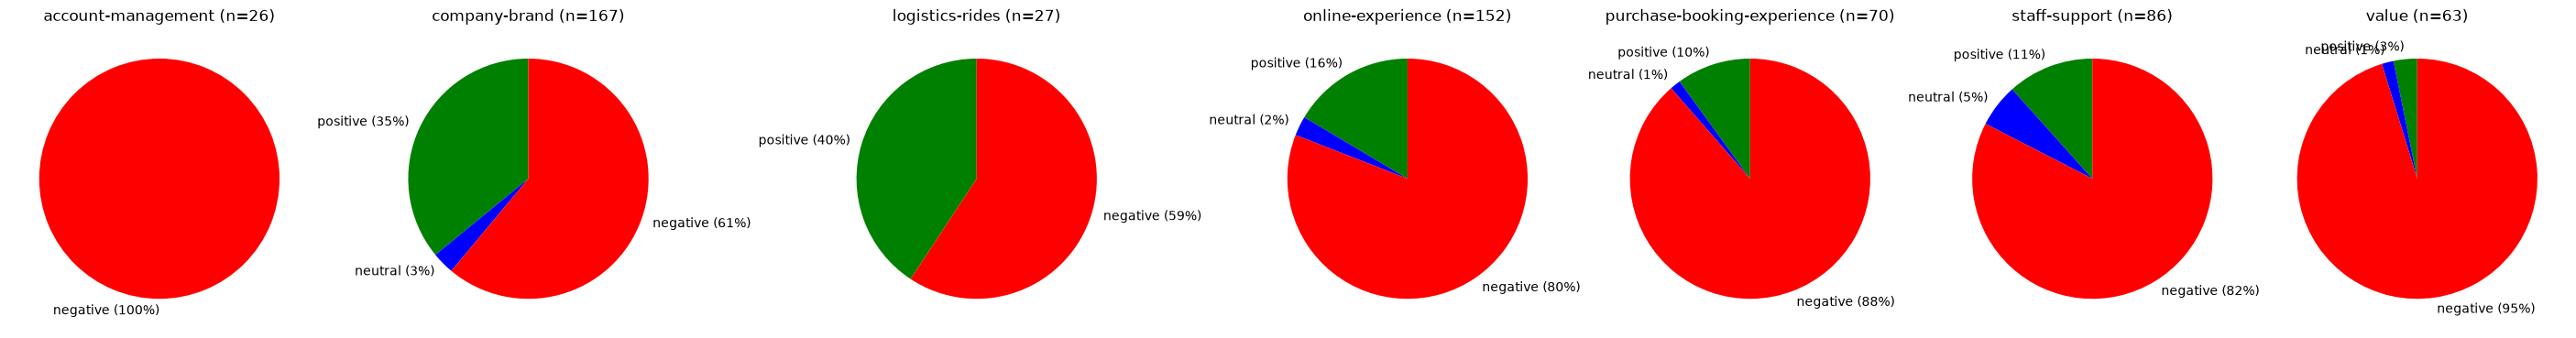

In [12]:
# plot pie charts

d2_parent_aspects = d2_counts['parent_aspect'].unique()
num_plots = len(d2_parent_aspects)
d2_counts['pct_round'] = d2_counts['percentage'].round(1).astype(int)

color_map = {
    "negative": "red",
    "neutral": "blue",
    "positive": "green"
}

fig, axes = plt.subplots(1, num_plots, figsize=(4*num_plots, 4), constrained_layout=True)

for ax, pa in zip(axes, d2_parent_aspects):
    subset = d2_counts[d2_counts['parent_aspect']==pa].copy()
    values = subset["percentage"].values

    sent_labels = subset["sentiment"].values
    pct_labels = subset["pct_round"].astype(str).values
    text_labels = [f"{s} ({p}%)" for s, p in zip(sent_labels, pct_labels)]
    colors = [color_map[s] for s in sent_labels]

    wedges, texts = ax.pie(values, labels=text_labels, colors=colors, startangle=90, autopct=None)
    ax.set_title(f"{pa} (n={int(subset['total'].iloc[0])})")

Gold answer: Sentiment is mostly negative across all parent aspects in the ride hailing industry. The breakdown by parent aspect is:


- Company brand (n=167): 61% negative, 36% positive, 3% neutral
- Online experience (n=152): 81% negative, 16% positive, 3% neutral
- Purchase and booking experience (n=70): 89% negative, 10% positive, 1% neutral
- Staff support (n=86): 83% negative, 12% positive, 6% neutral
- Value perception (n=63): 95% negative, 3% positive, 2% neutral

Note: Percentages may sum to 99–101% due to rounding. Account management and Logistics and rides have been excluded from the analysis due to low volumes. 

### D2 tool path

In [13]:
d2_step1 = filter_data(df, industry='Ride Hailing')
d2_step2 = sentiment_breakdown(d2_step1, 'parent_aspect')
d2_step3 = apply_min_volume(d2_step2, min_volume=30)
d2_step4 = add_shares(d2_step3)
d2_step4

sentiment,parent_aspect,positive,negative,neutral,total,pos_share,neg_share,neu_share
1,company-brand,60,102,5,167,0.359,0.611,0.030
3,online-experience,25,123,4,152,0.164,0.809,0.026
4,purchase-booking-experience,7,62,1,70,0.100,0.886,0.014
5,staff-support,10,71,5,86,0.116,0.826,0.058
6,value,2,60,1,63,0.032,0.952,0.016


### D3. Which 3 child aspects show the most polarised sentiment for the price comparison industry?

My approach: Polarisation means how evenly split (mixed) positive vs negative reviews are for each aspect. Define polarisation = min(positive_share, negative_share) where shares are over positive and negative reviews only. This score has a max of 0.5 (perfect split) and min of 0 (one-sided).

In [14]:
# filter 
df_d3 = df[(df['industry']=="Price Comparison") & (df['sentiment'] != 'neutral')]

In [15]:
# pivot by child aspect and sentiment
d3_pivot = pd.pivot_table(df_d3, index="child_aspect", columns="sentiment",  aggfunc="size", fill_value=0)

In [16]:
# compute positive and negative shares
d3_pivot["total"] = d3_pivot.sum(axis=1)
d3_pivot['pos_share'] = d3_pivot["positive"] / d3_pivot["total"]
d3_pivot['neg_share'] = d3_pivot["negative"] / d3_pivot["total"]
d3_pivot.head(3)

sentiment,negative,positive,total,pos_share,neg_share
child_aspect,,,,,
account-access,25,3,28,0.107143,0.892857
app-website,147,190,337,0.563798,0.436202
attitude-of-staff,48,329,377,0.872679,0.127321


In [17]:
# polarisation metric and sanity check
d3_pivot["polarisation"] = d3_pivot[["pos_share", "neg_share"]].min(axis=1)
# check min and max
print(d3_pivot["polarisation"].min(), d3_pivot["polarisation"].max())

0.07746478873239436 0.49122807017543857


In [18]:
d3_pivot[['total','polarisation', 'pos_share', 'neg_share']].sort_values('polarisation', ascending=False)

sentiment,total,polarisation,pos_share,neg_share
child_aspect,,,,
discounts-promotions,57,0.491228,0.491228,0.508772
app-website,337,0.436202,0.563798,0.436202
email,46,0.391304,0.391304,0.608696
reviews,21,0.380952,0.380952,0.619048
phone,96,0.281250,0.718750,0.281250
general-satisfaction,430,0.220930,0.779070,0.220930
competitor,144,0.166667,0.833333,0.166667
price-value-for-money,424,0.141509,0.858491,0.141509
attitude-of-staff,377,0.127321,0.872679,0.127321


Gold answer: The top 3 child aspects that show the most polarised sentiment in the Price Comparison industry are: 
- Discounts and promotions (n=57, polarisation = 49%)
- App or website experience (n=337, polarisation = 43%)
- Email support (n=46, polarisation = 39%).

### D3 tool path

In [19]:
d3_step1 = filter_data(df, industry='Price Comparison')
d3_step2 = sentiment_breakdown(d3_step1, 'child_aspect')
d3_step3 = add_polarisation(d3_step2)
d3_step4 = apply_min_volume(d3_step3, min_volume=30, col='pol_volume')
d3_step5 = rank_top(d3_step4, by='polarisation', top_n=3)
d3_step5

sentiment,child_aspect,positive,negative,neutral,total,pol_volume,polarisation
0,discounts-promotions,28,29,1,58,57,0.491
1,app-website,190,147,1,338,337,0.436
2,email,18,28,0,46,46,0.391


## Inferential queries

In all inferential queries, I assume the minimum sample size for statistical significance = 30.

### I1: Is our banking app and website's (org_index = 514) sentiment worse than our peers?

In [20]:
# filter
df_i1 = df[(df['industry']=="Banking") & (df['child_aspect']=='app-website')]
df_i1_org = df_i1[df_i1['org_index']==514]
df_i1_ind = df_i1[df_i1['org_index']!=514]  # exclude our org to prevent self-contamination

In [21]:
# check volumes
n_org = len(df_i1_org)
n_ind = len(df_i1_ind)
print(n_org, n_ind)
# sufficient volumes (>30)

304 100


In [22]:
# compute negative share in both subsets
neg_share_org = (df_i1_org['sentiment']=="negative").mean()
neg_share_ind = (df_i1_ind['sentiment']=="negative").mean()
print(f'Negative share: Ours = {neg_share_org:.2f}, Industry = {neg_share_ind:.2f}')

Negative share: Ours = 0.35, Industry = 0.04


Gold answer: Yes. Our negative share for App and website experience (35%, n=304) is much higher than our peers in the Banking industry (4%, n=100).

### I1 tool path

In [26]:
i1_step1 = filter_data(df, industry='Banking', child_aspect='app-website')
i1_step2 = filter_data(i1_step1, org_index=514)          # org slice
i1_step3 = exclude(i1_step1, org_index=514)              # peers slice
i1_step4 = share_of(i1_step2, sentiment='negative')      # org neg_share
i1_step5 = share_of(i1_step3, sentiment='negative')      # peers neg_share
print(i1_step4, i1_step5)

{'n': 304, 'count': 107, 'share': 0.352} {'n': 100, 'count': 4, 'share': 0.04}


In [35]:
org_breakdown = sentiment_breakdown(i1_step2, group_by='sentiment')
ind_breakdown = sentiment_breakdown(i1_step3, group_by='sentiment')
print("org 514: ")
print(org_breakdown)
print("")
print("peers: ")
print(ind_breakdown)

org 514: 
sentiment sentiment  positive  negative  neutral  total
0          negative         0       107        0    107
1           neutral         0         0        1      1
2          positive       196         0        0    196

peers: 
sentiment sentiment  positive  negative  neutral  total
0          negative         0         4        0      4
1           neutral         0         0       96     96


### I2: What child aspects are driving negative reviews for trading apps on Apple Store?

In [23]:
# filter
df_i2 = df[(df['industry']=='Trading') & (df['data_source']=='Apple Store')]

In [24]:
# compute negative share per child aspect
i2_pivot = pd.pivot_table(df_i2, index="child_aspect", columns="sentiment",  aggfunc="size", fill_value=0)
i2_pivot["total"] = i2_pivot.sum(axis=1)
# only keep sufficient volume
i2_pivot = i2_pivot[i2_pivot["total"] >= 30]
i2_pivot['neg_share'] = i2_pivot["negative"] / i2_pivot["total"]
i2_pivot.sort_values(by=('neg_share'), ascending=False)

sentiment,negative,neutral,positive,total,neg_share
child_aspect,,,,,
app-website,45,2,93,140,0.321429
general-satisfaction,18,0,60,78,0.230769
ease-of-use,15,0,70,85,0.176471


Gold answer: App or website experience is the strongest driver of negative reviews for trading apps on Apple Store (32%, n=140), followed by General satisfaction (23%, n=78) and Ease of use (17%, n=85).

### I2 tool path

In [27]:
i2_step1 = filter_data(df, industry='Trading', data_source='Apple Store')
i2_step2 = sentiment_breakdown(i2_step1, group_by='child_aspect')
i2_step3 = apply_min_volume(i2_step2, min_volume=30)    
i2_step4 = add_shares(i2_step3)                          # pos_share, neg_share, neu_share
i2_step5 = rank_top(i2_step4, by='neg_share', top_n=3)
i2_step5 

sentiment,child_aspect,positive,negative,neutral,total,pos_share,neg_share,neu_share
0,app-website,93,45,2,140,0.664,0.321,0.014
1,general-satisfaction,60,18,0,78,0.769,0.231,0.000
2,ease-of-use,70,15,0,85,0.824,0.176,0.000


Note: The first 5 questions took me 4.5 hours to analyse without the use of AI.